<a href="https://colab.research.google.com/github/ghn9zh/DS3001-programming/blob/main/trees_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Trees
Do three questions.

In [10]:
! git clone https://github.com/ds4e/trees

fatal: destination path 'trees' already exists and is not an empty directory.


**Q1.** Please answer the following questions in your own words.

1. How are trees constructed?

2. How do trees handle non-linear relationships between variables? Compare this to linear models.

3. Why is the Gini a good loss function for categorical target variables?

4. Why do trees tend to overfit, and how can this tendency be constrained?

5. True or false, and explain: Trees only really perform well in situations with lots of categorical variables as features/covariates.

6. Why don't most versions of classification/regression tree concept allow for more than two branches after a split?

7. What are some heuristic ways you can examine a tree and decide whether it is probably over- or under-fitting?

1. Trees are built by recrusviely splitting the dataset based on features best seperate the target variable. As each node the algorithm searches for the best feature and threshold to plit the data into two groups. This keeps going until it meets a stopping condtion like min number of samples per node or max tree depth.

2. Trees capture non-linear relationships natrually because they divide the feature space into regions with different predicted values. Each split can follow a different variable and threshold. Linear models are different because they assume a straight-line relationship and find non-linearity difficult unless transformed features are added.

3. Gin impurity measures how often a randomly chosen elemnt woukd be labeled wrong if it were rnadomly assigned according to the distribution in a node. It's senstive to class distributions and helps the tree priotrize pure splits. This makes it effective for improving classifcaition accuracy during tree construction.

4. Tress tend to overfit because they keep splitting until each leaf perfectly fits the training data which captures noise instead of geenral patterns. This can be constrained by pruning the tree, limiting its deoth, setting a min number of smaples er leaf, or using more random methods like random forests. These techniques reduce complexity and improve the generilization of the data.

5. Flase. Trees preform well with categorical variables without needing uncoding, but they also work effectivrly eith numerical features. They are flexible with having different types of trees (regression and classification) which allows them to model both types of variables and their interactions. This makes them able to apply across many types of data sets.

6. Binary spits are simpler to compute and interpret and they allow for more precise divsions of the data. having more than two branches can increase complexty and lead to scattered splits with fewer samples per node. Binary trees also align better with algorhitms that are recursive.

7. An overfitting tree is sualy very deep with many small leaves with each fitting only a few samples. This preforms poorly on test data. An underitting tree is ually shallow with few splits and can have high erorr or bother training and test sets. Helpful ways to see how the tree if the tree is under/over fitting is examining leaf sizes and tree depth.

**Q2.** This is a case study on regression and classification trees.

1. Load `./data/cars_hw.csv`. How many observations and features/covariates/variables? What are the available variables? Take a look at the first few rows of data.

2. For the categorical variables `Make`, `Color`, `Body_type`, `No_of_Owners`, `Fuel_Type`, `Transmission`, and `Transmission_Type`, create dummy/one-hot-encoded representations. For numeric variables, we'll use `Mileage_Run`, `Make_Year`, and `Seating_Capacity`. Our target variable will be `Price`. Make a train-test split of your data.

3. From `sklearn.tree`, import the `DecisionTreeRegressor` and `plot_tree`. Use a train-test split to iterate over possible values for `min_samples_leaf`, computing the $R^2$ for each value between 1 and 25. What choice achieves the highest $R^2$ on the test data?

4. For the optimal `min_samples_leaf` from 3, regress price on the rest of the features/covariates using the training data. What is your $R^2$ and RMSE on the test set? Plot the dendrogram. Plot the residuals. Is the density of residuals symmetric and centered around 0?

4. Run a linear regression of price on the same variables. Which model -- regression tree or linear regression -- performs better on the test set? Why?

5. Predict prices using both your tree and your linear model, and make a scatter plot of their values. Describe what you see.

In [3]:
#Question 2.1

import pandas as pd
file_path ='/content/trees/assignment/data/cars_hw.csv'
data = pd.read_csv(file_path)

data_shape=data.shape
data_columns=data.columns
data_head=data.head()

data_shape, data_columns, data_head

#Number of Observations: 976
#Number of variables/features: 11
#Available variabes: make, make_year, color, body_type, milage_run, No_of_owners,
#Seating_Capacity, Fuel_Type, Transmission, Tranmission_type, Price

((976, 12),
 Index(['Unnamed: 0', 'Make', 'Make_Year', 'Color', 'Body_Type', 'Mileage_Run',
        'No_of_Owners', 'Seating_Capacity', 'Fuel_Type', 'Transmission',
        'Transmission_Type', 'Price'],
       dtype='object'),
    Unnamed: 0        Make  Make_Year   Color  Body_Type  Mileage_Run  \
 0           1  Volkswagen       2017  silver      sedan        44611   
 1           2     Hyundai       2016     red  crossover        20305   
 2           3       Honda       2019   white        suv        29540   
 3           4     Renault       2017  bronze  hatchback        35680   
 4           5     Hyundai       2017  orange  hatchback        25126   
 
   No_of_Owners  Seating_Capacity Fuel_Type Transmission Transmission_Type  \
 0          1st                 5    diesel      7-Speed         Automatic   
 1          1st                 5    petrol      5-Speed            Manual   
 2          2nd                 5    petrol      5-Speed            Manual   
 3          1st     

In [4]:
#Question 2.2

from sklearn.model_selection import train_test_split
import pandas as pd

#drop the unnamed index column
data = data.drop(columns=["Unnamed: 0"])

#categorical and numeric features
categorical_vars = ['Make', 'Color', 'Body_Type', 'No_of_Owners', 'Fuel_Type', 'Transmission', 'Transmission_Type']
numeric_vars = ['Mileage_Run', 'Make_Year', 'Seating_Capacity']
target_var = 'Price'

# One-hot encode categorical variables
data_encoded = pd.get_dummies(data[categorical_vars + numeric_vars], drop_first=True)

X = data_encoded
y = data[target_var]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((780, 45), (196, 45), (780,), (196,))

In [5]:
#Question 2.3

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

# Iterate over min_samples_leaf from 1 to 25
r2_scores = {}
for leaf in range(1, 26):
    tree = DecisionTreeRegressor(min_samples_leaf=leaf, random_state=42)
    tree.fit(X_train, y_train)
    y_pred = tree.predict(X_test)
    r2_scores[leaf] = r2_score(y_test, y_pred)

# Find min_samples_leaf with the highest R²
best_leaf = max(r2_scores, key=r2_scores.get)
best_r2 = r2_scores[best_leaf]

best_leaf, best_r2

#The best value for min_samples_leaf is 5 and it acheives the highest R²= 0.825.

(5, 0.8253410511223336)

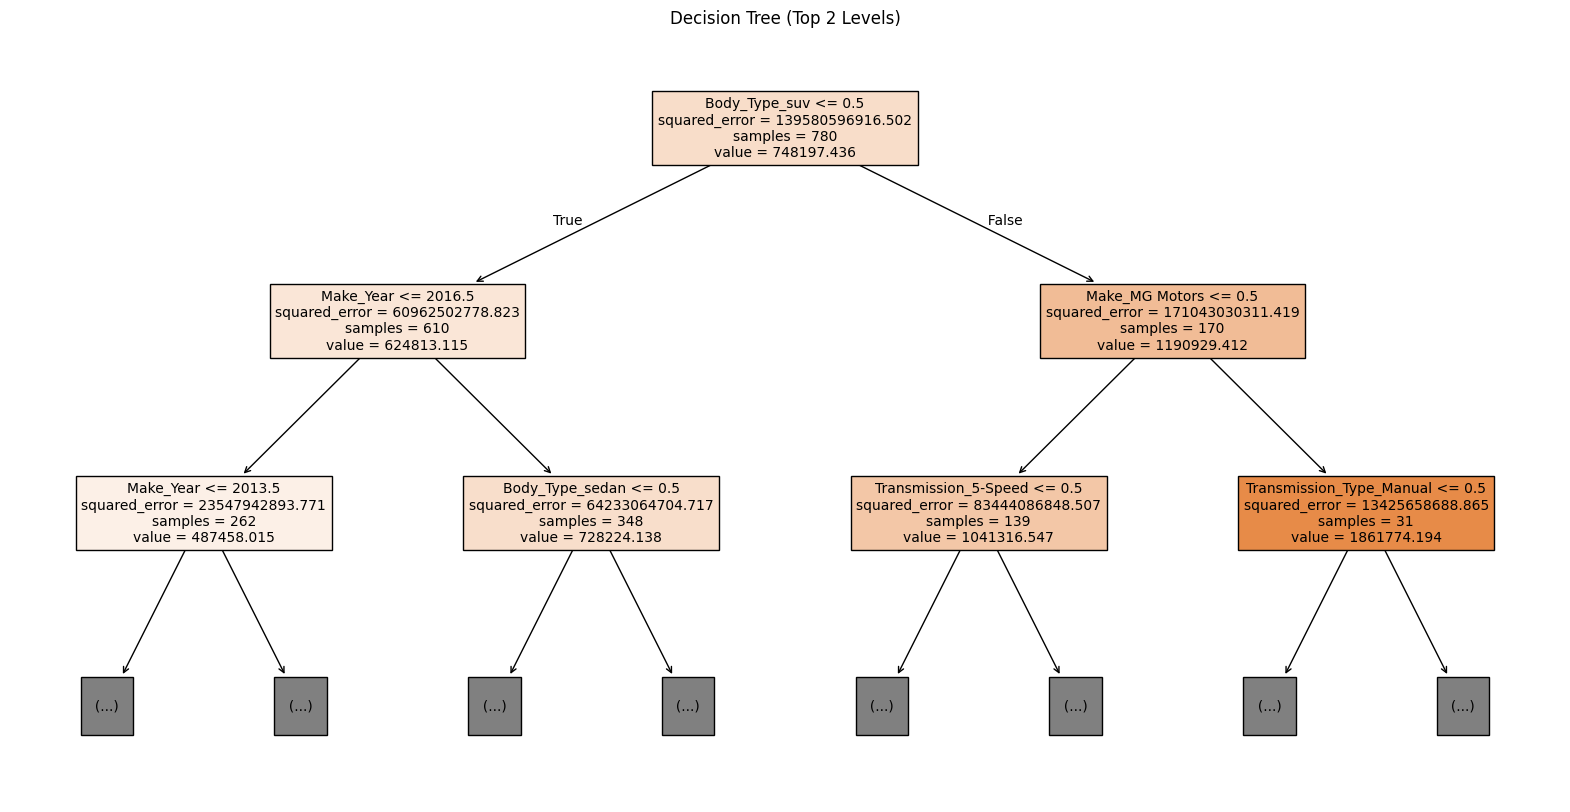

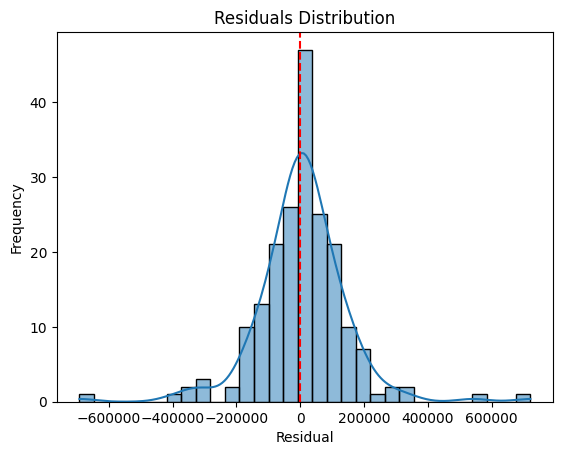

(0.8253410511223336, np.float64(141536.54096868183))

In [6]:
#Question 2.4

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.metrics import mean_squared_error
import numpy as np
import seaborn as sns

# Train the final model
final_tree = DecisionTreeRegressor(min_samples_leaf=5, random_state=42)
final_tree.fit(X_train, y_train)
y_pred_test = final_tree.predict(X_test)

# Calculate R² and RMSE
r2_final = r2_score(y_test, y_pred_test)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_test))

# Plot the decision tree (dendrogram)
plt.figure(figsize=(20, 10))
plot_tree(final_tree, feature_names=X.columns, filled=True, max_depth=2, fontsize=10)
plt.title("Decision Tree (Top 2 Levels)")
plt.show()

# Plot residuals
residuals = y_test - y_pred_test
sns.histplot(residuals, kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.title("Residuals Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

r2_final, rmse_final

#R2 = .0825, RSME= 141,537
#The density of residuals are pretty symmetric and centered around zero

In [8]:
#Question 2.5

from sklearn.linear_model import LinearRegression

# Train linear regression model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lr = lin_reg.predict(X_test)

# Calculate R² and RMSE for linear regression
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

r2_lr, rmse_lr

#R2: 0.820, RSME= 143,575
#The tree preforms slightly better on the test set with its R2=.825 and RSEM= 141,537
#The tree can capture non-linear patterns better bc the linear regression in limited
#to the linear relationship between features and price.

(0.8202733305970802, np.float64(143575.19660662542))

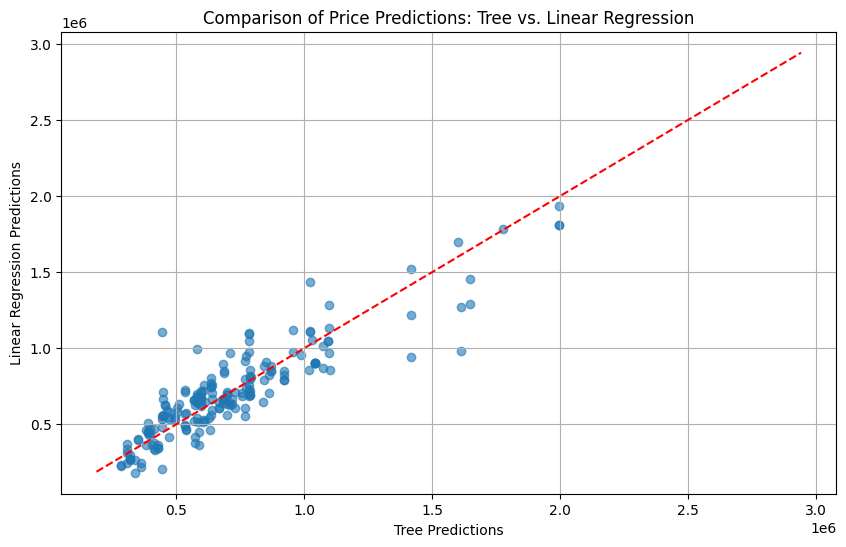

In [9]:
#Question 2.6

# Scatter plot comparing predictions from tree vs. linear regression
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_test, y_pred_lr, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Tree Predictions")
plt.ylabel("Linear Regression Predictions")
plt.title("Comparison of Price Predictions: Tree vs. Linear Regression")
plt.grid(True)
plt.show()

#The scatter plot shows that the prediction from the regression tree and linear
#regression are generally correlated and cluster around the diagonal line which
#represents perfect agreement. The tree predictions shows more variability which
#means it is capturing more patters that the linear regression just smooths over.

**Q3.** This is a case study about classification and regression trees.

1. Load the `Breast Cancer METABRIC.csv` dataset. How many observations and variables does it contain? Print out the first few rows of data.

2.  We'll use a consistent set of feature/explanatory variables. For numeric variables, we'll include `Tumor Size`, `Lymph nodes examined positive`, `Age at Diagnosis`. For categorical variables, we'll include `Tumor Stage`, `Chemotherapy`, and `Cancer Type Detailed`. One-hot-encode the categorical variables and concatenate them with the numeric variables into a feature/covariate matrix, $X$.

3. Let's predict `Overall Survival Status` given the features/covariates $X$. There are 528 missing values, unfortunately: Either drop those rows from your data or add them as a category to predict. Constrain the minimum samples per leaf to 10. Print a dendrogram of the tree. Print a confusion matrix of the algorithm's performance. What is the accuracy?

4. For your model in part three, compute three statistics:
    - The **true positive rate** or **sensitivity**:
        $$
        TPR = \dfrac{TP}{TP+FN}
        $$
    - The **true negative rate** or **specificity**:
        $$
        TNR = \dfrac{TN}{TN+FP}
        $$
    Does your model tend to perform better with respect to one of these metrics?

5. Let's predict `Overall Survival (Months)` given the features/covariates $X$. Use the train/test split to pick the optimal `min_samples_leaf` value that gives the highest $R^2$ on the test set (it's about 110). What is the $R^2$? Plot the test values against the predicted values. How do you feel about this model for clinical purposes?

**Q4.** This is a case study about trees using bond rating data. This is a dataset about bond ratings for different companies, alongside a bunch of business statistics and other data. Companies often have multiple reviews at different dates. We want to predict the bond rating (AAA, AA, A, BBB, BB, B, ..., C, D). Do business fundamentals predict the company's rating?

1. Load the `./data/corporate_ratings.csv` dataset. How many observations and variables does it contain? Print out the first few rows of data.

2.  Plot a histogram of the `ratings` variable. It turns out that the gradations of AAA/AA/A and BBB/BB/B and so on make it hard to get good results with trees. Collapse all AAA/AA/A ratings into just A, and similarly for B and C.

3. Use all of the variables **except** Rating, Date, Name, Symbol, and Rating Agency Name. To include Sector, make a dummy/one-hot-encoded representation and include it in your features/covariates. Collect the relevant variables into a data matrix $X$.

4. Do a train/test split of the data and use a decision tree classifier to predict the bond rating. Including a min_samples_leaf constraint can raise the accuracy and speed up computation time. Print a confusion matrix and the accuracy of your model. How well do you predict the different bond ratings?

5. If you include the rating agency as a feature/covariate/predictor variable, do the results change? How do you interpret this?

In [11]:
#Question 4.1

import pandas as pd

bond_data = pd.read_csv('/content/trees/assignment/data/corporate_ratings.csv')

bond_shape = bond_data.shape
bond_head = bond_data.head()

bond_shape, bond_head

#Number of observations: 2,029
#Number of variables: 31

((2029, 31),
   Rating                   Name Symbol                  Rating Agency Name  \
 0      A  Whirlpool Corporation    WHR          Egan-Jones Ratings Company   
 1    BBB  Whirlpool Corporation    WHR          Egan-Jones Ratings Company   
 2    BBB  Whirlpool Corporation    WHR                       Fitch Ratings   
 3    BBB  Whirlpool Corporation    WHR                       Fitch Ratings   
 4    BBB  Whirlpool Corporation    WHR  Standard & Poor's Ratings Services   
 
          Date             Sector  currentRatio  quickRatio  cashRatio  \
 0  11/27/2015  Consumer Durables      0.945894    0.426395   0.099690   
 1   2/13/2014  Consumer Durables      1.033559    0.498234   0.203120   
 2    3/6/2015  Consumer Durables      0.963703    0.451505   0.122099   
 3   6/15/2012  Consumer Durables      1.019851    0.510402   0.176116   
 4  10/24/2016  Consumer Durables      0.957844    0.495432   0.141608   
 
    daysOfSalesOutstanding  ...  effectiveTaxRate  \
 0          

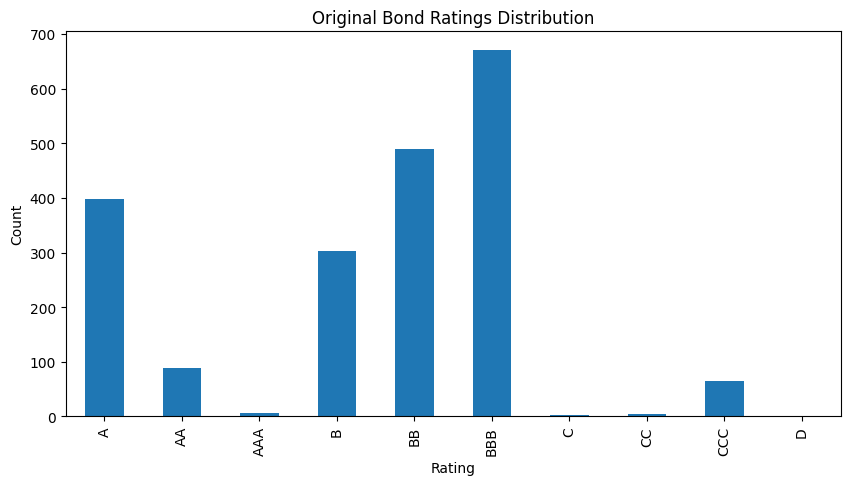

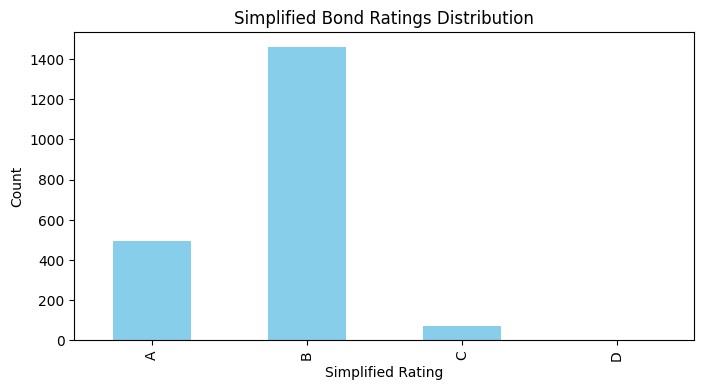

In [12]:
#Question 4.2

import matplotlib.pyplot as plt

#original ratings distribution
plt.figure(figsize=(10, 5))
bond_data['Rating'].value_counts().sort_index().plot(kind='bar')
plt.title("Original Bond Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

# make rating groups
def simplify_rating(rating):
    if rating in ['AAA', 'AA', 'A']:
        return 'A'
    elif rating in ['BBB', 'BB', 'B']:
        return 'B'
    elif rating in ['CCC', 'CC', 'C']:
        return 'C'
    else:
        return rating  # e.g., D remains D

bond_data['Rating_Simple'] = bond_data['Rating'].apply(simplify_rating)

# Plot the new ratings distribution
plt.figure(figsize=(8, 4))
bond_data['Rating_Simple'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title("Simplified Bond Ratings Distribution")
plt.xlabel("Simplified Rating")
plt.ylabel("Count")
plt.show()

In [13]:
#Question 4.3

# Drop non-feature columns
drop_cols = ['Rating', 'Date', 'Name', 'Symbol', 'Rating Agency Name']
features = bond_data.drop(columns=drop_cols + ['Rating_Simple'])

# One-hot encode
features = pd.get_dummies(features, columns=['Sector'], drop_first=True)

#matrix X and target y
X = features
y = bond_data['Rating_Simple']

X.shape, y.shape

#final feature matrix X has 36 features

((2029, 36), (2029,))

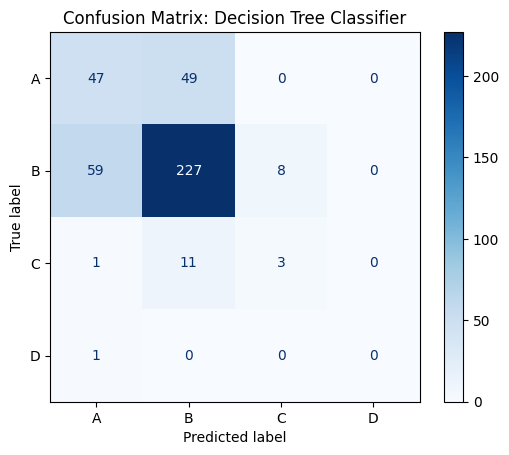

0.6822660098522167

In [14]:
#Question 4.4

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Decision Tree Classifier
clf = DecisionTreeClassifier(min_samples_leaf=10, random_state=42)
clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred, labels=['A', 'B', 'C', 'D'])

# Plot matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['A', 'B', 'C', 'D'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix: Decision Tree Classifier")
plt.show()

acc

#The accuracy of the decission tree classifier is 68.2%
#The confusion matrix did reasoanbly well ar preditcing A and B rating but had
#some confusion with C and D this was probably due to fewer examples and more noise
#in those classes.

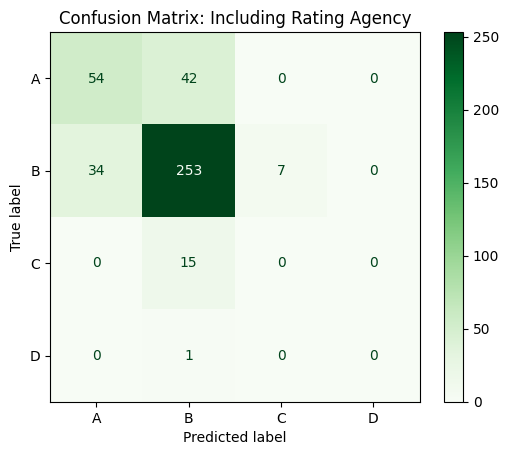

0.7561576354679803

In [15]:
#Question 4.5

data_full = pd.read_csv('/content/trees/assignment/data/corporate_ratings.csv')
data_full['Rating_Simple'] = data_full['Rating'].apply(simplify_rating)

# Drop irrelevant columns
drop_cols_full = ['Rating', 'Date', 'Name', 'Symbol']
features_with_agency = data_full.drop(columns=drop_cols_full + ['Rating_Simple'])

# One-hot encode both 'Sector' and 'Rating Agency Name'
features_encoded = pd.get_dummies(features_with_agency, columns=['Sector', 'Rating Agency Name'], drop_first=True)

X_with_agency = features_encoded
y_with_agency = data_full['Rating_Simple']

# Train-test split and model training
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(X_with_agency, y_with_agency, test_size=0.2, random_state=42)
clf_with_agency = DecisionTreeClassifier(min_samples_leaf=10, random_state=42)
clf_with_agency.fit(X_train_a, y_train_a)

# Predictions and evaluation
y_pred_a = clf_with_agency.predict(X_test_a)
acc_with_agency = accuracy_score(y_test_a, y_pred_a)
cm_with_agency = confusion_matrix(y_test_a, y_pred_a, labels=['A', 'B', 'C', 'D'])

# Plot confusion matrix
ConfusionMatrixDisplay(confusion_matrix=cm_with_agency, display_labels=['A', 'B', 'C', 'D']).plot(cmap='Greens')
plt.title("Confusion Matrix: Including Rating Agency")
plt.show()

acc_with_agency

#With including Rating Agency Name as a preditor the model's accuracy improved
#to 75.6% rrom 68.2%.
#This model siggets that different rating agencies might use slightley different
#criteria for each bond rating label which the second model can pick up on to
#imporve predictions.

**Q5.** This is a case study about detecting fraud using classification trees. The goal is to predict the `class` variable, which is 0 for non-fraud and 1 for fraud.

1. Open `./data/creditcard_fraud.csv`. Print the number of observations and variables, and look at the first few rows of data. The variables are already normalized and de-identified, and are just called things like `V8` to protect the privacy of the clients.

2. Print a table of counts for the `class` variable and make a histogram. What percentage of transactions are fraudulent?

3. Drop `Time` and make a decision tree classifier to predict fraud. Print a confusion table and compute the accuracy. This is a serious **class imbalance** problem: The minority class is so small that essentially predicting 0's for all cases will achieve an extremely high accuracy. There are over-sampling techniques to deal with this issue, but we don't have time to cover them in class.

4. Imagine that you block every transaction in the test set labelled as fraudulent. How much money is (1) saved that should be saved, (2) lost to fraud anyway, (3) withheld in error from customers? Does implementing this anti-fraud system seem like a good idea, or not? Why?

5. Instead of predicting fraud, predict loss: Multiple the `Class` variable times the `Amount` variable, and call it `Loss`. Predict it using a decision tree regressor (making sure to drop Class, Time, and Loss from the features/covariates/predictors). What $R^2$ and RMSE do you get? Make a scatterplot of the predicted values on the test group versus the actual test values. Do you notice any interesting patterns? How could you use this algorithm to decide which transactions to block, and why?


**Q6.** Show that any decision tree is equivalent to a linear regression on a set of dummy variables that represent the optimal splits in the tree.

Hint: You can think of CART as partitioning the feature space into a set of sets $\{S_1, S_2, ..., S_K\}$, and then predicting the average for all of the observations in each set $S_k$, $m_k$:
$$
\hat{y}(x) = \sum_{k=1}^K \mathbb{I}\{ x \text{ is in } S_k \} m_k
$$
where $\mathbb{I} \{ P(x,k)\}$ takes the value 1 if the proposition $P(x,k)$ is true and 0 otherwise. Now, doesn't that look like least-squares regression on a set of dummy/one-hot-encoded variables?

Conversely, can any linear regression be represented by a tree?